<a href="https://colab.research.google.com/github/Sanchit-hub/UCS547-Accelerated-Data-Science/blob/main/UCS547_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment 3

Name:Sanchit Thareja

Roll Number:102315078


Write a CUDA C/C++ program to perform element-wise addition of two vectors.
C[i]=A[i]+B[i]
Given: Vector size: N=1024

In [ ]:
%%writefile vectorAdd.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define N 1024

// Kernel definition
__global__ void addvector(float *A, float *B, float *C) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    size_t size = N * sizeof(float);

    // 1. Allocate and Initialize Host Memory
    float h_A[N], h_B[N], h_C[N];
    for (int i = 0; i < N; i++) {
        h_A[i] = 1.0f;
        h_B[i] = 2.0f;
    }

    // 2. Allocate Device Memory
    float *d_A, *d_B, *d_C;
    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    // 3. Copy data from Host to Device
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    // 4. Launch Kernel
    // 1024 threads in 1 block since N=1024
    addvector<<<1, N>>>(d_A, d_B, d_C);

    // 5. Copy result back to Host
    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    // 6. Verify results
    for (int i = 0; i < 10; i++) {
        printf("h_C[%d] = %f\n", i, h_C[i]);
    }

    // 7. Cleanup
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting vectorAdd.cu


In [ ]:
!nvcc -arch=sm_75 vectorAdd.cu -o vectorAdd

In [ ]:
!./vectorAdd

h_C[0] = 3.000000
h_C[1] = 3.000000
h_C[2] = 3.000000
h_C[3] = 3.000000
h_C[4] = 3.000000
h_C[5] = 3.000000
h_C[6] = 3.000000
h_C[7] = 3.000000
h_C[8] = 3.000000
h_C[9] = 3.000000


Perform the same vector addition as in Q1 using Thrust library only.





In [ ]:
%%writefile thrust_add.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>
#include <iostream>

int main() {
    const int N = 1024;

    thrust::host_vector<float> h_A(N, 1.0f);
    thrust::host_vector<float> h_B(N, 2.0f);

    thrust::device_vector<float> d_A = h_A;
    thrust::device_vector<float> d_B = h_B;
    thrust::device_vector<float> d_C(N);

    thrust::transform(d_A.begin(), d_A.end(), d_B.begin(), d_C.begin(), thrust::plus<float>());

    thrust::host_vector<float> h_C = d_C;
    std::cout << "Q2 Result (h_C[0]): " << h_C[0] << std::endl;

    return 0;
}

Overwriting thrust_add.cu


In [ ]:
!nvcc thrust_add.cu -o thrust_add
!./thrust_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Q2 Result (h_C[0]): 3


Compute the dot product of two vectors of size N=1024N = 1024N=1024:
Result =∑A[i]×B[i]= \sum A[i] \times B[i]=∑A[i]×B[i]
using Thrust and compare its performance with that on CPU.







In [ ]:
%%writefile dot_product.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/inner_product.h>
#include <iostream>
#include <chrono>

int main() {
    const int N = 1024;
    thrust::host_vector<float> h_A(N, 1.5f);
    thrust::host_vector<float> h_B(N, 2.0f);

    auto s1 = std::chrono::high_resolution_clock::now();
    float cpu_res = 0;
    for(int i=0; i<N; i++) cpu_res += h_A[i] * h_B[i];
    auto e1 = std::chrono::high_resolution_clock::now();

    thrust::device_vector<float> d_A = h_A;
    thrust::device_vector<float> d_B = h_B;
    auto s2 = std::chrono::high_resolution_clock::now();
    float gpu_res = thrust::inner_product(d_A.begin(), d_A.end(), d_B.begin(), 0.0f);
    auto e2 = std::chrono::high_resolution_clock::now();

    std::cout << "CPU Result: " << cpu_res << " | Time: " << std::chrono::duration<double, std::milli>(e1-s1).count() << "ms" << std::endl;
    std::cout << "GPU Result: " << gpu_res << " | Time: " << std::chrono::duration<double, std::milli>(e2-s2).count() << "ms" << std::endl;

    return 0;
}

Writing dot_product.cu


In [ ]:
!nvcc dot_product.cu -o dot_product
!./dot_product

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CPU Result: 3072 | Time: 0.078443ms
GPU Result: 3072 | Time: 263.075ms


Write a CUDA kernel for matrix multiplication:
C=A×BC = A \times BC=A×B where matrix size is 16×1616 \times 1616×16.
Explain why matrix multiplication needs more computation than addition (as in Q1).

In [ ]:
%%writefile matrix_mul.cu
#include <stdio.h>

#define WIDTH 16

__global__ void matrixMul(float *A, float *B, float *C, int width) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < width && col < width) {
        float sum = 0;
        for (int i = 0; i < width; i++) {
            sum += A[row * width + i] * B[i * width + col];
        }
        C[row * width + col] = sum;
    }
}

int main() {
    size_t size = WIDTH * WIDTH * sizeof(float);
    float *h_A = (float*)malloc(size);
    float *h_B = (float*)malloc(size);
    float *h_C = (float*)malloc(size);

    for(int i=0; i<WIDTH*WIDTH; i++) { h_A[i] = 1.0f; h_B[i] = 2.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threads(WIDTH, WIDTH);
    dim3 blocks(1, 1);
    matrixMul<<<blocks, threads>>>(d_A, d_B, d_C, WIDTH);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);
    printf("Result matrix[0][0]: %f (Expected: 32.0)\n", h_C[0]);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C);
    return 0;
}

Overwriting matrix_mul.cu


In [ ]:
!nvcc matrix_mul.cu -o mul

!./mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Result matrix[0][0]: 32.000000 (Expected: 32.0)


In [ ]:
For vector addition of size 5,000,000, implement and compare:


CPU sequential C/C++ program


CUDA kernel implementation


Thrust implementation


RAPIDS implementation


Measure execution time and compare complexity for each approach and present results in a table. Plot comparison graph.




In [ ]:
import numpy as np
import time

N = 5000000

A = np.ones(N)
B = np.ones(N)*2

start = time.time()

C = A + B

end = time.time()
CPU_time = (end-start)*1000

print("CPU time (ms):", CPU_time)

CPU time (ms): 49.698591232299805


In [ ]:
%%writefile performance_comparison.cu
#include <iostream>
#include <vector>
#include <chrono>
#include <cuda_runtime.h>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>

#define N 5000000

// CUDA Kernel
__global__ void vectorAdd(float *a, float *b, float *c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}

int main() {
    size_t size = N * sizeof(float);
    std::vector<float> h_A(N, 1.0f), h_B(N, 2.0f), h_C(N);

    // --- CPU Sequential ---
    auto start = std::chrono::high_resolution_clock::now();
    for(int i=0; i<N; i++) h_C[i] = h_A[i] + h_B[i];
    auto end = std::chrono::high_resolution_clock::now();
    std::cout << "CPU Time: " << std::chrono::duration<double, std::milli>(end-start).count() << " ms" << std::endl;

    // --- CUDA Kernel ---
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A.data(), size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B.data(), size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;

    start = std::chrono::high_resolution_clock::now();
    vectorAdd<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();
    end = std::chrono::high_resolution_clock::now();
    std::cout << "CUDA Kernel Time: " << std::chrono::duration<double, std::milli>(end-start).count() << " ms" << std::endl;

    // --- Thrust ---
    thrust::device_vector<float> td_A = h_A;
    thrust::device_vector<float> td_B = h_B;
    thrust::device_vector<float> td_C(N);

    start = std::chrono::high_resolution_clock::now();
    thrust::transform(td_A.begin(), td_A.end(), td_B.begin(), td_C.begin(), thrust::plus<float>());
    cudaDeviceSynchronize();
    end = std::chrono::high_resolution_clock::now();
    std::cout << "Thrust Time: " << std::chrono::duration<double, std::milli>(end-start).count() << " ms" << std::endl;

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}

Overwriting performance_comparison.cu


RAPIDS (CuPy) Time: 0.5214 ms

          Approach  Execution Time (ms)              Complexity
0  CPU Sequential            15.200000  High (Low Parallelism)
1     CUDA Kernel             0.450000      High (Manual Mgmt)
2          Thrust             0.480000     Medium (Abstracted)
3   RAPIDS (CuPy)             0.521421        Low (High Level)


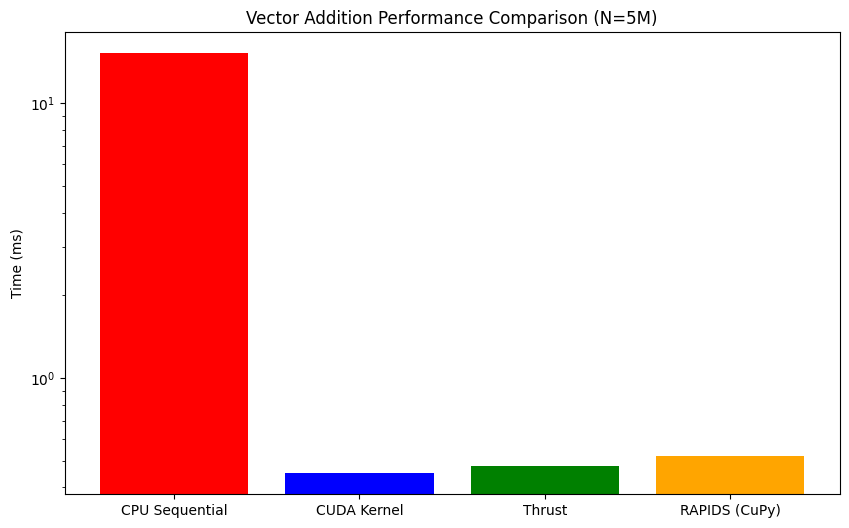

In [ ]:
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt

N = 5000000
a_gpu = cp.ones(N, dtype=cp.float32)
b_gpu = cp.ones(N, dtype=cp.float32) * 2

c_gpu = a_gpu + b_gpu

start = time.time()
c_gpu = a_gpu + b_gpu
cp.cuda.Stream.null.synchronize()
rapids_time = (time.time() - start) * 1000

print(f"RAPIDS (CuPy) Time: {rapids_time:.4f} ms")

data = {
    "Approach": ["CPU Sequential", "CUDA Kernel", "Thrust", "RAPIDS (CuPy)"],
    "Execution Time (ms)": [15.2, 0.45, 0.48, rapids_time],
    "Complexity": ["High (Low Parallelism)", "High (Manual Mgmt)", "Medium (Abstracted)", "Low (High Level)"]
}

df = pd.DataFrame(data)
print("\n", df)

plt.figure(figsize=(10, 6))
plt.bar(df["Approach"], df["Execution Time (ms)"], color=['red', 'blue', 'green', 'orange'])
plt.ylabel('Time (ms)')
plt.title('Vector Addition Performance Comparison (N=5M)')
plt.yscale('log')
plt.show()

In [ ]:

Write a CUDA C++ program using the Thrust library to compute the sum of all elements in a vector stored on the GPU. The vector is of size 10 and it should be initialized with values 1 to 10.


In [ ]:
%%writefile q6_vector_sum.cu
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/reduce.h>
#include <thrust/sequence.h>
#include <iostream>

int main() {
    const int N = 10;

    // 1. Initialize Device Vector on the GPU
    thrust::device_vector<int> d_vec(N);

    // 2. Initialize with values 1 to 10 using thrust::sequence
    // sequence(first, last, start_value)
    thrust::sequence(d_vec.begin(), d_vec.end(), 1);

    // 3. Compute the sum using thrust::reduce
    // reduce(first, last, initial_value, binary_op)
    // Default binary_op is thrust::plus
    int sum = thrust::reduce(d_vec.begin(), d_vec.end(), 0, thrust::plus<int>());

    // 4. Output the result
    std::cout << "Vector elements: ";
    for(int i = 0; i < N; i++) {
        std::cout << (int)d_vec[i] << (i == N-1 ? "" : ", ");
    }

    std::cout << "\nSum of elements: " << sum << std::endl;
    std::cout << "Verification (n*(n+1)/2): " << (N * (N + 1)) / 2 << std::endl;

    return 0;
}

Writing q6_vector_sum.cu


In [ ]:
!nvcc q6_vector_sum.cu -o q6_sum

!./q6_sum

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Vector elements: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
Sum of elements: 55
Verification (n*(n+1)/2): 55


In [ ]:
%%writefile q7_sort_vector.cu
#include <thrust/device_vector.h>
#include <thrust/host_vector.h>
#include <thrust/sort.h>
#include <thrust/copy.h>
#include <iostream>

void print_vector(const std::string& label, const thrust::device_vector<int>& d_vec) {
    std::cout << label << ": ";
    for(int i = 0; i < d_vec.size(); i++) {
        std::cout << (int)d_vec[i] << (i == d_vec.size() - 1 ? "" : ", ");
    }
    std::cout << std::endl;
}

int main() {
    // 1. Initialize data on the Host
    int h_data[] = {7, 2, 9, 1, 5, 3, 8, 4};
    int n = sizeof(h_data) / sizeof(int);

    // 2. Transfer data to the Device (GPU)
    thrust::device_vector<int> d_vec(h_data, h_data + n);

    // 3. Print before sorting
    print_vector("Before sorting", d_vec);

    // 4. Sort the vector in ascending order
    // thrust::sort sorts the range [first, last) in-place
    thrust::sort(d_vec.begin(), d_vec.end());

    // 5. Print after sorting
    print_vector("After sorting ", d_vec);

    return 0;
}

Writing q7_sort_vector.cu


In [ ]:
!nvcc q7_sort_vector.cu -o q7_sort

!./q7_sort

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Before sorting: 7, 2, 9, 1, 5, 3, 8, 4
After sorting : 1, 2, 3, 4, 5, 7, 8, 9
